In [17]:
import pandas as pd    
import json
import matplotlib.pyplot as plt
import sys
import os
import importlib
import subprocess

sys.path.append('../utils/')
from vllm_server import *
from notebook_utils import *
import vllm_server
import notebook_utils

importlib.reload(vllm_server)
importlib.reload(notebook_utils)


<module 'notebook_utils' from '/home/p316289/Desktop/work/dl-mig-contention-aware-system/experiments/notebooks/../utils/notebook_utils.py'>

In [6]:
EXP_RESULTS_PATH="../results/"
EXP_NAME="ram_bandwidth_stress_1v1"
EXP_CPU_OFFLOAD_FLAG="_cpuoffload-on" # _cpuoffload-off in case of unsetting cpu offloading
EXP_ARTIFACTS_TAR="artifacts.tar.gz"
EXP_METADATA="run_metadata.json"
EXP_METRICS="system_metrics.tar.gz"
EXP_PHASE= ["baseline", "wram_stress"]

In [7]:
# Work on Latest Exp, unless stated otherwise
EXP_PATH_PRE=EXP_RESULTS_PATH + EXP_NAME + EXP_CPU_OFFLOAD_FLAG

latest_exp_dir = get_latest_experiment_dir(EXP_RESULTS_PATH, EXP_PATH_PRE)

if latest_exp_dir:
    print(f"Latest experiment directory: {latest_exp_dir}")
else:
    print("No matching experiment directory found.")

Latest experiment directory: ../results/../results/ram_bandwidth_stress_1v1_cpuoffload-on_20260930T004307


In [8]:
# Print experiment metadata
with open(f"{latest_exp_dir}/{EXP_METADATA}", 'r') as f:
    metadata = json.load(f)
    print(json.dumps(metadata, indent=2))

{
  "cpu_offload_by_model": {
    "Qwen/Qwen2.5-1.5B-Instruct": "0.2",
    "Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8": "0.2",
    "RedHatAI/SmolLM-1.7B-Instruct-quantized.w8a16": "0.2",
    "RedHatAI/gemma-2-2b-it-quantized.w4a16": "0.1"
  },
  "cpu_offload_enabled": true,
  "git_commit": "5a5af56774d98ed282998ee7776bb5468e854a99",
  "models": [
    "RedHatAI/gemma-2-2b-it-quantized.w4a16",
    "RedHatAI/SmolLM-1.7B-Instruct-quantized.w8a16",
    "Qwen/Qwen2.5-1.5B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8"
  ],
  "request_count": [
    "200"
  ],
  "request_rate": [
    "10"
  ],
  "run_id": "ram_bandwidth_stress_1v1_cpuoffload-on_20260930T004307",
  "timestamp": "20260930T004307"
}


In [9]:
# Extract artifacts and system metrics
if not os.path.exists(f"/tmp/{str(latest_exp_dir).split('/')[-1]}"):
    os.mkdir(f"/tmp/{str(latest_exp_dir).split('/')[-1]}")

EXP_TMP=f"/tmp/{str(latest_exp_dir).split('/')[-1]}"
subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{EXP_ARTIFACTS_TAR}", "-C", EXP_TMP])
subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{EXP_METRICS}", "-C", EXP_TMP])

CompletedProcess(args=['tar', '-xf', '../results/../results/ram_bandwidth_stress_1v1_cpuoffload-on_20260930T004307/system_metrics.tar.gz', '-C', '/tmp/ram_bandwidth_stress_1v1_cpuoffload-on_20260930T004307'], returncode=0)

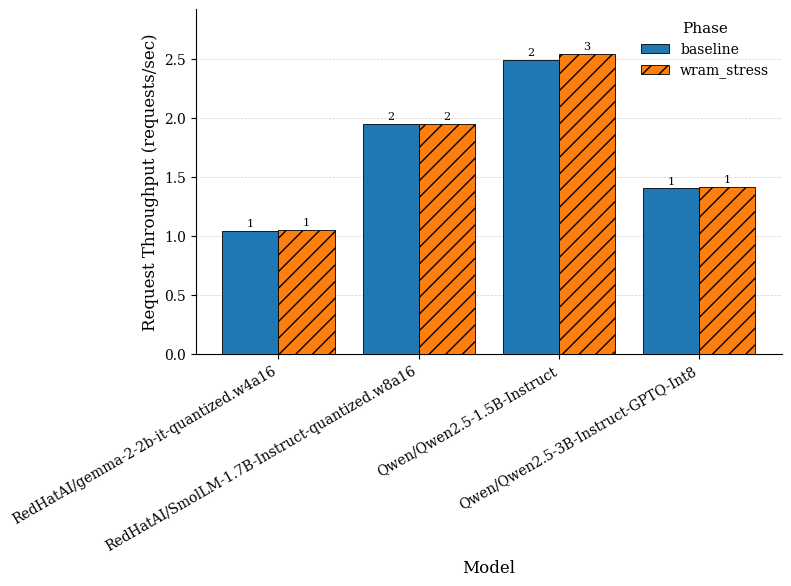

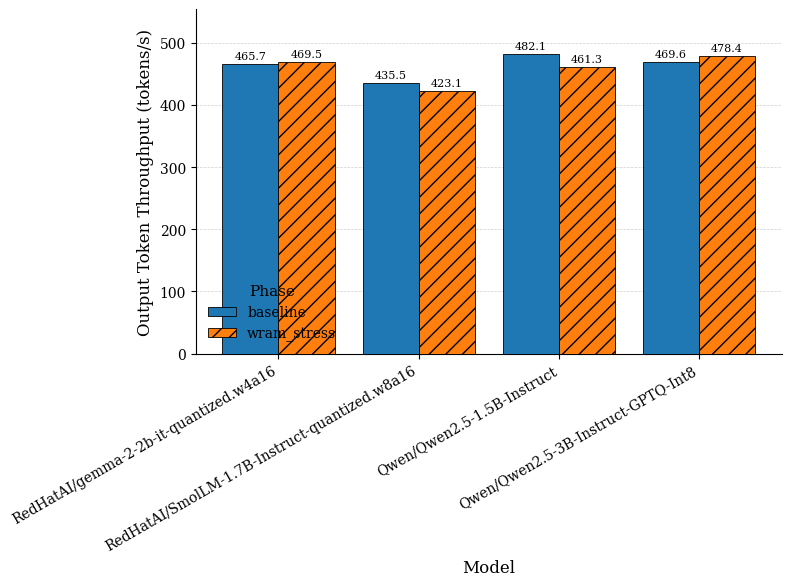

In [18]:
# Plot baseline vs stress performance
import numpy as np

results = []

for rps in metadata["request_rate"]:
    for n in metadata["request_count"]:
        for MODEL_NAME in metadata["models"]:
            for phase in EXP_PHASE:
                file = EXP_TMP + "/artifacts/" + f"{phase}/" + f"{MODEL_NAME.replace('/','_')}_rps{rps}_n{n}/" + f"{phase}.csv"
                df = read_summary_report(file)
                results.append({
                    "Model": MODEL_NAME,
                    "Mode": phase,
                    "Request Throughput": df.loc[df["Metric"] == "Request Throughput (requests/sec)", "Value"].item(),
                    "Output Token Throughput": (
                        df.loc[df["Metric"] == "Output Token Throughput (tokens/sec)", "Value"].item()
                    ),
                    "rps": rps,
                    "n" : n
                })

results_df = pd.DataFrame(results)
plot_throughput_and_rps(metadata["models"], results_df, EXP_PHASE, save_prefix=f"{EXP_NAME}_request_rate")

In [32]:
# Plot baseline vs stress performance
import numpy as np

results = []

model_to_pod = {
    "Qwen/Qwen2.5-1.5B-Instruct": "qwen25-1o5b",
    "Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8": "qwen25-3b",
    "RedHatAI/SmolLM-1.7B-Instruct-quantized.w8a16": "smollm-1o7b",
    "RedHatAI/gemma-2-2b-it-quantized.w4a16": "gemma-4-e2b"
}

for rps in metadata["request_rate"]:
    for n in metadata["request_count"]:
        for MODEL_NAME in metadata["models"]:
            for phase in ["wram_stress"]:
                file = EXP_TMP + f"/{phase}__" + f"{MODEL_NAME.replace('/','_')}_rps{rps}_n{n}.csv"
                df = pd.read_csv(file)
                results.append({
                    "Model": MODEL_NAME,
                    "Mode": phase,
                    "CPU Usage": df.loc[(df["metric"] == "pod_cpu_usage_cores") & (df["labels"].str.contains(model_to_pod[MODEL_NAME])), "value"].mean(),
                })

results_df = pd.DataFrame(results)


In [33]:
results_df

,Model,Mode,CPU Usage
0,RedHatAI/gemma-2-2b-it-quantized.w4a16,wram_stress,0.171455
1,RedHatAI/SmolLM-1.7B-Instruct-quantized.w8a16,wram_stress,0.087640
2,Qwen/Qwen2.5-1.5B-Instruct,wram_stress,0.057832
3,Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8,wram_stress,0.108995


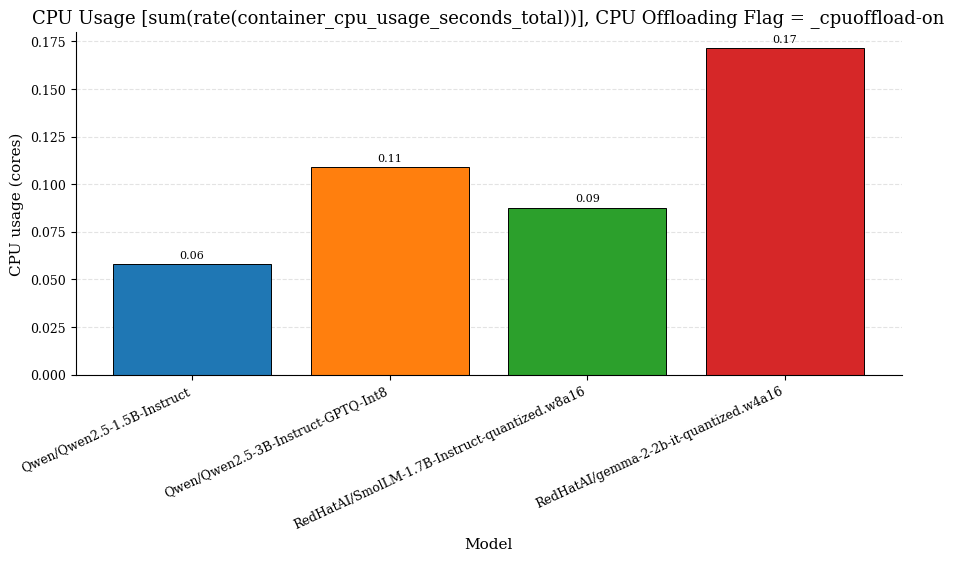

In [38]:
if "CPU Usage" not in results_df.columns:
    raise ValueError("Run cell 6 first; results_df must contain a 'CPU Usage' column.")

# Average across repeated measurements, if present.
cpu_by_model = results_df.groupby("Model")["CPU Usage"].mean()

with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}):
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    colors = plt.get_cmap("tab10").colors[:len(cpu_by_model)]

    bars = ax.bar(
        range(len(cpu_by_model)),
        cpu_by_model.values,
        color=colors,
        edgecolor="black",
        linewidth=0.7,
        label="Mean CPU usage",
    )

    ax.set_xticks(range(len(cpu_by_model)))
    ax.set_xticklabels(cpu_by_model.index, rotation=25, ha="right")
    ax.set_xlabel("Model")
    ax.set_ylabel("CPU usage (cores)")
    ax.set_title(f"CPU Usage [sum(rate(container_cpu_usage_seconds_total))], CPU Offloading Flag = {EXP_CPU_OFFLOAD_FLAG}")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    #ax.legend(frameon=False)

    for bar, value in zip(bars, cpu_by_model.values):
        ax.annotate(
            f"{value:.2f}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.show()
    fig.savefig(f"../figures/{EXP_NAME}_cpu_usage{EXP_CPU_OFFLOAD_FLAG}.png", dpi=300)